# Identitas Mahasiswa

Nama: Muhammad Sir Kafi El Migwar

NIM: 250401020081

Kelas: IF405

=== Shape Dataset ===
(150, 5)

=== Tipe Data ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

=== 5 Data Teratas ===
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

=== Statistik Deskriptif ===
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.80

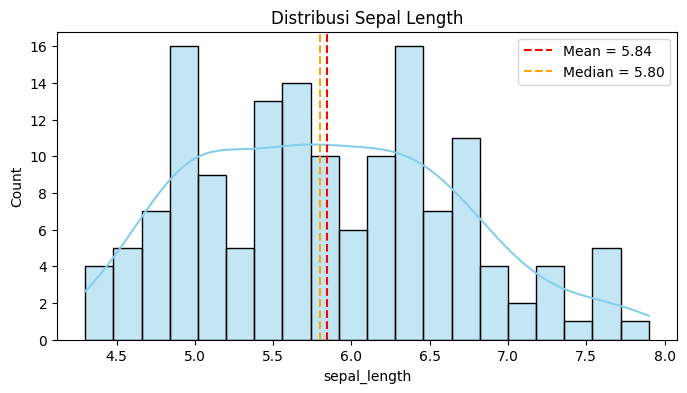

/tmp/ipykernel_15522/3185057838.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15522/3185057838.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


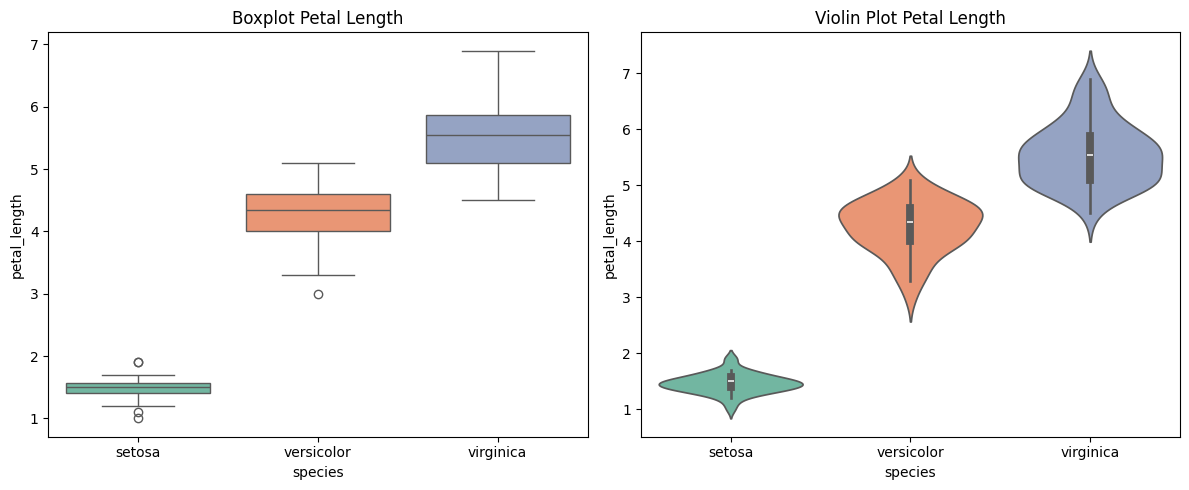


=== Matriks Korelasi ===
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi: ('petal_width', 'petal_length')
Nilai korelasi: 0.963


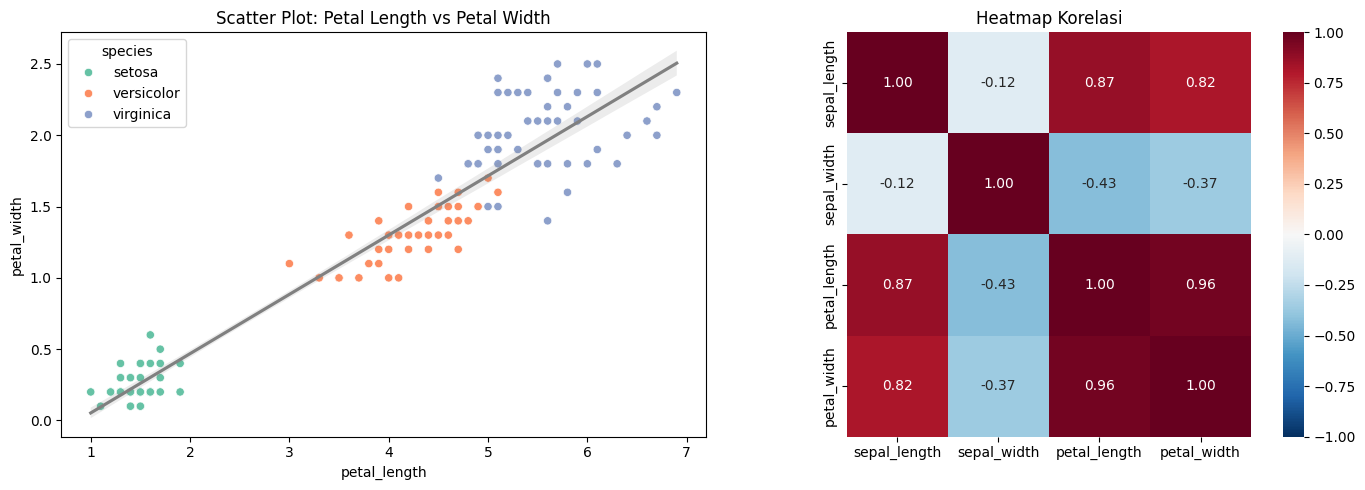

In [4]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# ==========================================
# Langkah 1: Load & Inspect Dataset
# ==========================================

df = sns.load_dataset('iris')

print("=== Shape Dataset ===")
print(df.shape)

print("\n=== Tipe Data ===")
print(df.dtypes)

print("\n=== 5 Data Teratas ===")
print(df.head())

print("\n=== Statistik Deskriptif ===")
print(df.describe().round(3))


# ==========================================
# Langkah 2: Statistik Deskriptif Lengkap
# ==========================================

print("\n===================================")
print("STATISTIK DESKRIPTIF LENGKAP")
print("===================================")

for col_name in df.select_dtypes(include='number').columns:

    col = df[col_name]

    print(f"\n=== {col_name} ===")
    print(f"Mean      : {col.mean():.3f}")
    print(f"Median    : {col.median():.3f}")
    print(f"Std Dev   : {col.std():.3f}")
    print(f"Varians   : {col.var():.3f}")
    print(f"Skewness  : {col.skew():.3f}")
    print(f"Kurtosis  : {col.kurt():.3f}")


# ==========================================
# Langkah 3: Histogram + KDE
# ==========================================

fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    df['sepal_length'],
    kde=True,
    bins=20,
    color='skyblue',
    ax=ax
)

ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title('Distribusi Sepal Length')
ax.legend()

plt.show()


# ==========================================
# Langkah 4: Boxplot per Species
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Boxplot Petal Length')

sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    inner='box',
    ax=axes[1]
)

axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()


# ==========================================
# Langkah 5: Matriks Korelasi Pearson
# ==========================================

corr = df.drop('species', axis=1).corr(method='pearson')

print("\n=== Matriks Korelasi ===")
print(corr.round(3))

# Cari korelasi tertinggi
mask = np.triu(np.ones(corr.shape)).astype(bool)

corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()

print(f"\nKorelasi tertinggi: {max_pair}")
print(f"Nilai korelasi: {corr.loc[max_pair]:.3f}")


# ==========================================
# Langkah 6: Scatter Plot & Heatmap
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter Plot: Petal Length vs Petal Width')

# Heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

## Kesimpulan Pembelajaran dari Analisis Data Iris

Dari analisis dataset Iris ini, saya mempelajari bagaimana memahami karakteristik data melalui berbagai teknik analisis statistik dan visualisasi data. Proses yang dilakukan meliputi pemeriksaan struktur dataset, analisis statistik deskriptif, identifikasi distribusi data, analisis korelasi antar fitur, serta visualisasi hubungan antar variabel.

Beberapa hal yang saya pelajari antara lain:

- Cara memeriksa struktur dataset untuk mengetahui jumlah data, tipe data, serta memastikan tidak terdapat nilai yang hilang.
- Cara menggunakan statistik deskriptif seperti mean, median, minimum, maksimum, dan standar deviasi untuk memahami karakteristik setiap fitur.
- Cara menganalisis distribusi data menggunakan histogram dan kurva kepadatan (KDE) untuk melihat pola penyebaran data.
- Cara membandingkan karakteristik antar spesies Iris menggunakan box plot dan violin plot sehingga perbedaan setiap kelompok dapat terlihat dengan lebih jelas.
- Cara menghitung dan menginterpretasikan korelasi antar fitur menggunakan korelasi Pearson untuk mengetahui hubungan antar variabel numerik.
- Cara menggunakan scatter plot dan heatmap untuk memvisualisasikan hubungan antar variabel serta menemukan pola yang tersembunyi dalam dataset.
- Pentingnya visualisasi data sebagai alat untuk membantu memahami informasi dan menarik insight dari data dengan lebih mudah.

Secara keseluruhan, analisis dataset Iris memberikan pemahaman yang lebih baik mengenai penggunaan statistik deskriptif, korelasi, dan visualisasi data dalam proses analisis. Selain itu, saya juga memahami bahwa setiap fitur memiliki kontribusi yang berbeda dalam membedakan karakteristik masing-masing spesies Iris.